# Analysis of COVID-era changes in incarcerated populations

This notebook analyzes state-level prison population data from the Dataset on Incarcerated Populations, created for the paper “COVID-19 amplified racial disparities in the U.S. criminal legal system.”

The goal is to examine how incarcerated populations changed during the COVID-19 period and whether those changes were evenly distributed across racial groups.

In [29]:
# Import pandas for data analysis, matplotlib for charting, and pathlib for creating folders
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [43]:
# Load the state-level prison population dataset

url = "https://raw.githubusercontent.com/diyajain13/covid-prison-population-data-story/main/data/populations_states.csv"

df = pd.read_csv(url)

df.head()

,date,data_or_inferred,incarcerated_total,incarcerated_white,incarcerated_black,incarcerated_hispanic,incarcerated_amerind,incarcerated_asian,incarcerated_other,incarcerated_unknown,incarcerated_nonwhite,state,url
0,2000-01-01,raw data,25213.0,8753,16382.0,NaN,NaN,NaN,78.0,NaN,16460.0,Alabama,http://www.doc.state.al.us/StatReports
1,2000-02-01,raw data,25213.0,8753,16382.0,NaN,NaN,NaN,78.0,NaN,16460.0,Alabama,http://www.doc.state.al.us/StatReports
2,2000-03-01,raw data,25161.0,8723,16361.0,NaN,NaN,NaN,77.0,NaN,16438.0,Alabama,http://www.doc.state.al.us/StatReports
3,2000-04-01,raw data,25200.0,8738,16380.0,NaN,NaN,NaN,82.0,NaN,16462.0,Alabama,http://www.doc.state.al.us/StatReports
4,2000-05-01,raw data,25226.0,8788,16358.0,NaN,NaN,NaN,80.0,NaN,16438.0,Alabama,http://www.doc.state.al.us/StatReports


In [44]:
# Look at column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9585 entries, 0 to 9584
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   9585 non-null   object 
 1   data_or_inferred       9585 non-null   object 
 2   incarcerated_total     9585 non-null   float64
 3   incarcerated_white     9585 non-null   int64  
 4   incarcerated_black     9308 non-null   float64
 5   incarcerated_hispanic  5743 non-null   float64
 6   incarcerated_amerind   7245 non-null   float64
 7   incarcerated_asian     6726 non-null   float64
 8   incarcerated_other     6067 non-null   float64
 9   incarcerated_unknown   3968 non-null   float64
 10  incarcerated_nonwhite  9585 non-null   float64
 11  state                  9585 non-null   object 
 12  url                    9585 non-null   object 
dtypes: float64(8), int64(1), object(4)
memory usage: 973.6+ KB


In [45]:
# Check how many missing values appear in each column
df.isna().sum()

,0
date,0
data_or_inferred,0
incarcerated_total,0
incarcerated_white,0
incarcerated_black,277
incarcerated_hispanic,3842
incarcerated_amerind,2340
incarcerated_asian,2859
incarcerated_other,3518
incarcerated_unknown,5617


In [46]:
df["date"].head()

,date
0,2000-01-01
1,2000-02-01
2,2000-03-01
3,2000-04-01
4,2000-05-01


In [47]:
# Convert the date column into datetime format so the data can be filtered and charted over time
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

df[["date", "year", "state", "incarcerated_total"]].head()

,date,year,state,incarcerated_total
0,2000-01-01,2000,Alabama,25213.0
1,2000-02-01,2000,Alabama,25213.0
2,2000-03-01,2000,Alabama,25161.0
3,2000-04-01,2000,Alabama,25200.0
4,2000-05-01,2000,Alabama,25226.0


In [48]:
# Create a folder where chart image files will be saved
Path("charts").mkdir(exist_ok=True)

## Preparing the COVID-era subset

For the main visual analysis, I focused on the period from 2018 through 2022. This gives some pre-pandemic context, the first year of COVID-19, and the years immediately after. I grouped the state-level data by month to estimate national-level trends across the states included in the dataset.

In [49]:
# Focus on the years before, during, and immediately after the first year of COVID-19
covid_df = df[(df["date"] >= "2018-01-01") & (df["date"] <= "2022-12-31")].copy()

covid_df.head()

,date,data_or_inferred,incarcerated_total,incarcerated_white,incarcerated_black,incarcerated_hispanic,incarcerated_amerind,incarcerated_asian,incarcerated_other,incarcerated_unknown,incarcerated_nonwhite,state,url,year
216,2018-01-01,raw data,27686.0,12635,14899.0,NaN,NaN,NaN,152.0,NaN,15051.0,Alabama,http://www.doc.state.al.us/StatReports,2018
217,2018-02-01,raw data,27343.0,12512,14677.0,NaN,NaN,NaN,154.0,NaN,14831.0,Alabama,http://www.doc.state.al.us/StatReports,2018
218,2018-03-01,raw data,27081.0,12410,14516.0,NaN,NaN,NaN,155.0,NaN,14671.0,Alabama,http://www.doc.state.al.us/StatReports,2018
219,2018-04-01,raw data,26897.0,12362,14378.0,NaN,NaN,NaN,157.0,NaN,14535.0,Alabama,http://www.doc.state.al.us/StatReports,2018
220,2018-05-01,raw data,26931.0,12385,14381.0,NaN,NaN,NaN,165.0,NaN,14546.0,Alabama,http://www.doc.state.al.us/StatReports,2018


In [50]:
# Sum state-level prison populations by date to estimate the national monthly trend
national_monthly = (
    covid_df.groupby("date")["incarcerated_total"]
    .sum()
    .reset_index()
)

national_monthly.head()

,date,incarcerated_total
0,2018-01-01,1459689.0
1,2018-02-01,1455792.0
2,2018-03-01,1456246.0
3,2018-04-01,1457061.0
4,2018-05-01,1454862.0


## Chart 1: Total prison population over time

This chart shows how the total incarcerated population changed from 2018 through 2022 across the state-level data. The goal is to show the broad trend before, during, and after the first year of the COVID-19 pandemic.

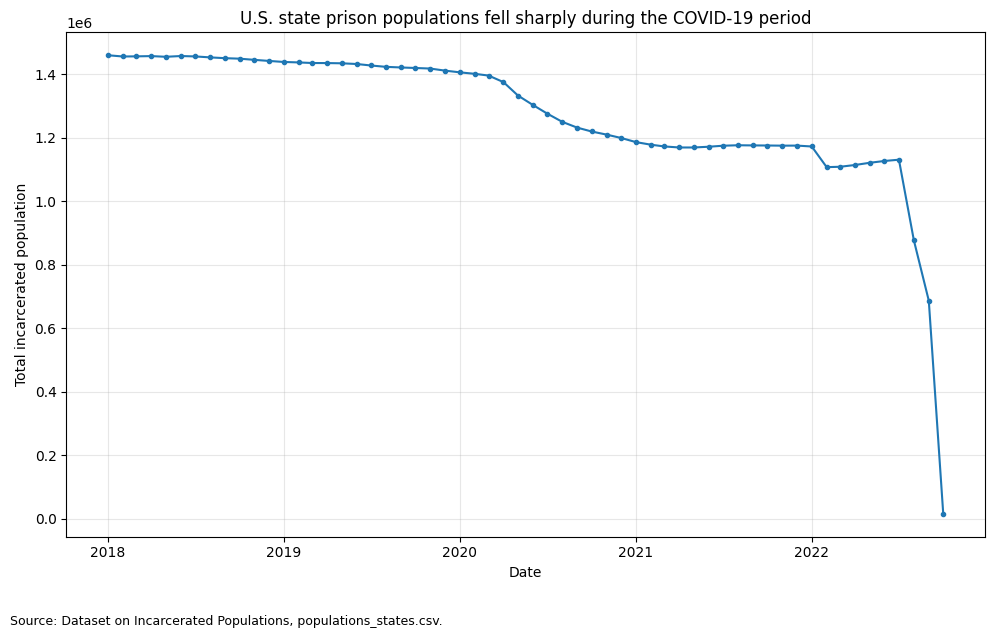

In [51]:
# Create and save the first visualization which is total incarcerated population over time
plt.figure(figsize=(10, 6))

plt.plot(
    national_monthly["date"],
    national_monthly["incarcerated_total"],
    marker="o",
    markersize=3
)

plt.title("U.S. state prison populations fell sharply during the COVID-19 period")
plt.xlabel("Date")
plt.ylabel("Total incarcerated population")
plt.grid(True, alpha=0.3)

plt.figtext(
    0.01,
    -0.05,
    "Source: Dataset on Incarcerated Populations, populations_states.csv.",
    ha="left",
    fontsize=9
)

plt.tight_layout()
plt.savefig("charts/chart1_total_prison_population.png", dpi=300, bbox_inches="tight")
plt.show()

## Chart 2: Racial composition over time

This chart compares the share of the counted White, Black, and Hispanic incarcerated populations over time. I calculated each group's share using only the White, Black, and Hispanic count columns, because these are the racial/ethnic categories most directly relevant to the project's question.

In [52]:
# Sum White, Black, and Hispanic incarcerated population counts by date
race_monthly = (
    covid_df.groupby("date")[
        [
            "incarcerated_white",
            "incarcerated_black",
            "incarcerated_hispanic"
        ]
    ]
    .sum()
    .reset_index()
)
# Use the counted racial/ethnic groups as the denominator for calculating shares
race_monthly["counted_total"] = (
    race_monthly["incarcerated_white"] +
    race_monthly["incarcerated_black"] +
    race_monthly["incarcerated_hispanic"]
)

# Calculate each group's share of the counted White, Black, and Hispanic incarcerated population
race_monthly["white_share"] = race_monthly["incarcerated_white"] / race_monthly["counted_total"] * 100
race_monthly["black_share"] = race_monthly["incarcerated_black"] / race_monthly["counted_total"] * 100
race_monthly["hispanic_share"] = race_monthly["incarcerated_hispanic"] / race_monthly["counted_total"] * 100

race_monthly.head()

,date,incarcerated_white,incarcerated_black,incarcerated_hispanic,counted_total,white_share,black_share,hispanic_share
0,2018-01-01,639111,556776.0,185373.0,1381260.0,46.270145,40.309283,13.420573
1,2018-02-01,638266,555089.0,184541.0,1377896.0,46.321783,40.285261,13.392956
2,2018-03-01,638782,554583.0,184358.0,1377723.0,46.365053,40.253592,13.381355
3,2018-04-01,639765,554125.0,184516.0,1378406.0,46.413393,40.200420,13.386187
4,2018-05-01,639137,553069.0,184443.0,1376649.0,46.427012,40.175019,13.397969


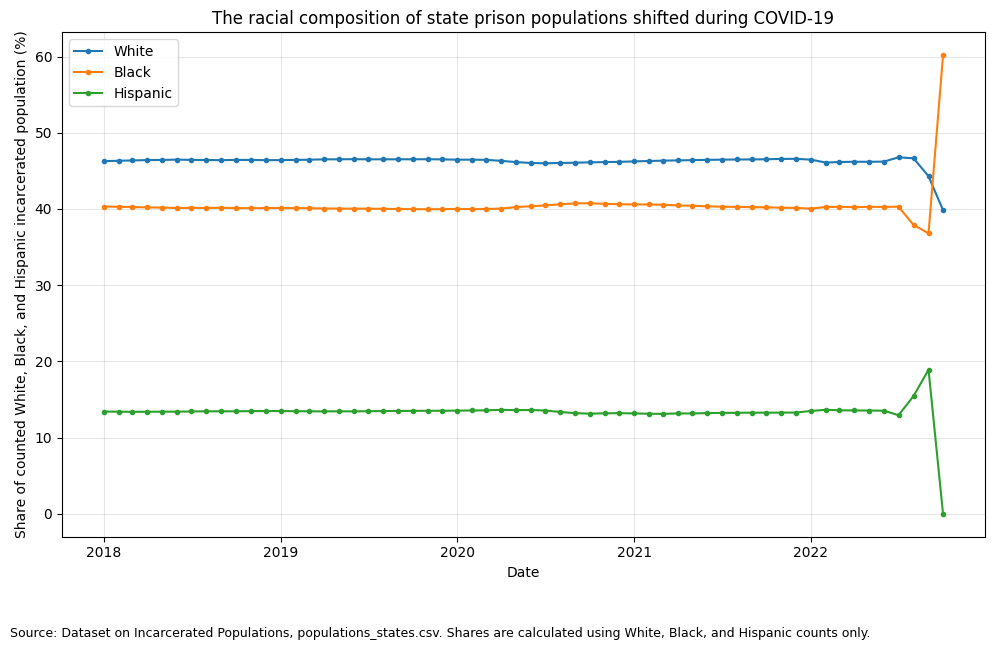

In [53]:
# Create and save the second visualization which is racial composition over time
plt.figure(figsize=(10, 6))

plt.plot(
    race_monthly["date"],
    race_monthly["white_share"],
    marker="o",
    markersize=3,
    label="White"
)

plt.plot(
    race_monthly["date"],
    race_monthly["black_share"],
    marker="o",
    markersize=3,
    label="Black"
)

plt.plot(
    race_monthly["date"],
    race_monthly["hispanic_share"],
    marker="o",
    markersize=3,
    label="Hispanic"
)

plt.title("The racial composition of state prison populations shifted during COVID-19")
plt.xlabel("Date")
plt.ylabel("Share of counted White, Black, and Hispanic incarcerated population (%)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.figtext(
    0.01,
    -0.07,
    "Source: Dataset on Incarcerated Populations, populations_states.csv. Shares are calculated using White, Black, and Hispanic counts only.",
    ha="left",
    fontsize=9
)

plt.tight_layout()
plt.savefig("charts/chart2_racial_composition.png", dpi=300, bbox_inches="tight")
plt.show()